In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')


In [17]:
files = [
    'flight_data_BOM_BLR.csv',
    'flight_data_DEL_BLR.csv',
    'flight_data_DEL_BOM.csv',
    'flight_data_DEL_CCU.csv',
    'flight_data_DEL_HYD.csv'
]

Data Pipeline

In [18]:
df_list = []
for file in files:
    try:
        df = pd.read_csv(file)
        # Extract route name cleanly from filename
        route = file.replace('flight_data_', '').replace('.csv', '').replace('_', '-')
        df['Route'] = route
        df_list.append(df)
    except FileNotFoundError:
        print(f"File {file} not found. Skipping...")

# Concatenate into one master dataset
master_df = pd.concat(df_list, ignore_index=True)



Clean pricing data (remove commas and quotes)

In [21]:

master_df['Price'] = master_df['Price'].astype(str).str.replace(',', '').str.replace('"', '').astype(float)

 Calculate True Baseline Prices per Route

In [22]:
base_prices = master_df.groupby('Route')['Price'].median().to_dict()

print("✅ Network Data Pipeline Established.")
print("\nRegional Baseline Fares Computed:")
for route, price in base_prices.items():
    print(f" - {route}: ₹{price:,.2f}")

✅ Network Data Pipeline Established.

Regional Baseline Fares Computed:
 - BOM-BLR: ₹4,621.00
 - DEL-BLR: ₹5,717.00
 - DEL-BOM: ₹4,780.00
 - DEL-CCU: ₹6,020.00
 - DEL-HYD: ₹4,986.00


In [24]:
# Network Parameters
TOTAL_DAYS = 90
CAPACITY = 250
master_simulation_log = []
network_kpis = []




# Loop through the network, running the simulation for each unique route

In [25]:
for route, base_price in base_prices.items():
    seats_remaining = CAPACITY
    cumulative_revenue = 0
    
    # Unique seed per route to simulate slightly different market behaviors
    np.random.seed(hash(route) % (2**32)) 
    
    for days_left in range(TOTAL_DAYS, 0, -1):
        day_index = TOTAL_DAYS - days_left + 1
        
        # 1. ALGORITHMIC PRICING
        time_progress = 1 - (days_left / TOTAL_DAYS)
        load_factor = (CAPACITY - seats_remaining) / CAPACITY
        
        # Base Multiplier + Time Premium + Scarcity Exponential Penalty
        price_multiplier = 0.70 + (0.50 * time_progress) + (1.2 * (load_factor ** 2))
        current_price = base_price * price_multiplier
        
        # 2. DEMAND SIMULATION (Poisson + Elasticity)
        expected_daily_demand = 3.5 + (2.0 * time_progress)
        base_demand = np.random.poisson(lam=expected_daily_demand)
        
        expected_market_price = base_price * (1 + time_progress * 0.2)
        price_elasticity = expected_market_price / current_price
        
        actual_demand = max(0, int(base_demand * (price_elasticity ** 1.5)))
        bookings_today = min(actual_demand, seats_remaining)
        
        # 3. UPDATE ROUTE METRICS
        daily_revenue = bookings_today * current_price
        cumulative_revenue += daily_revenue
        seats_remaining -= bookings_today
        
        master_simulation_log.append({
            'Route': route,
            'Days_to_Departure': days_left,
            'Ticket_Price_INR': round(current_price, 2),
            'Bookings': bookings_today,
            'Remaining_Seats': seats_remaining,
            'Cumulative_Revenue': round(cumulative_revenue, 2),
            'Load_Factor': round(load_factor, 3)
        })
        
        if seats_remaining <= 0:
            break
            
    # Record End-of-Simulation KPIs
    network_kpis.append({
        'Route': route,
        'Base_Price': base_price,
        'Total_Revenue_INR': cumulative_revenue,
        'Seats_Sold': CAPACITY - seats_remaining,
        'Final_Load_Factor_%': ((CAPACITY - seats_remaining)/CAPACITY)*100
    })

sim_df = pd.DataFrame(master_simulation_log)
kpi_df = pd.DataFrame(network_kpis)
print("✅ Network-Wide Yield Simulation Complete.")

✅ Network-Wide Yield Simulation Complete.


🎯 FINAL NETWORK ROUTE KPIs
  Route  Base_Price Total_Revenue_INR  Seats_Sold  Final_Load_Factor_%
BOM-BLR      4621.0     ₹1,445,105.99         250                100.0
DEL-BLR      5717.0     ₹1,591,773.63         229                 91.6
DEL-BOM      4780.0     ₹1,480,459.94         245                 98.0
DEL-CCU      6020.0     ₹1,759,672.23         238                 95.2
DEL-HYD      4986.0     ₹1,587,410.40         250                100.0


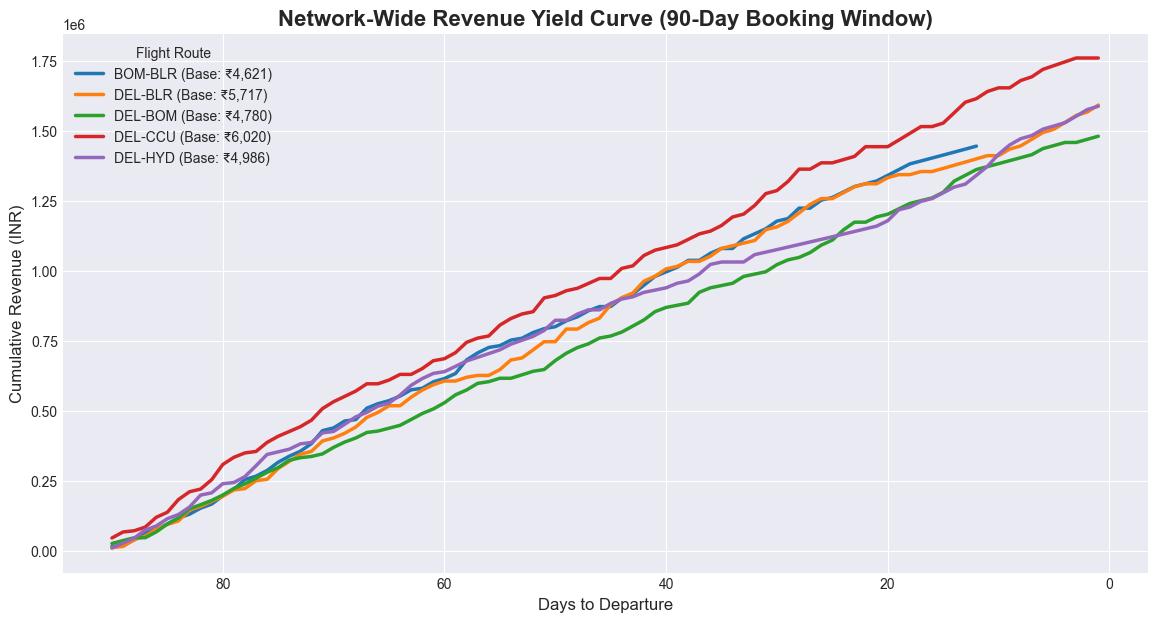

In [26]:
# Format the KPI output for a professional summary
kpi_df['Total_Revenue_INR'] = kpi_df['Total_Revenue_INR'].apply(lambda x: f"₹{x:,.2f}")
print("="*60)
print("🎯 FINAL NETWORK ROUTE KPIs")
print("="*60)
print(kpi_df.to_string(index=False))
print("="*60)

# Multi-Route Visualization: Revenue Accumulation
plt.figure(figsize=(14, 7))
for route in base_prices.keys():
    route_data = sim_df[sim_df['Route'] == route]
    plt.plot(route_data['Days_to_Departure'], route_data['Cumulative_Revenue'], 
             label=f"{route} (Base: ₹{base_prices[route]:,.0f})", linewidth=2.5)

plt.title('Network-Wide Revenue Yield Curve (90-Day Booking Window)', fontsize=16, fontweight='bold')
plt.xlabel('Days to Departure', fontsize=12)
plt.ylabel('Cumulative Revenue (INR)', fontsize=12)
plt.gca().invert_xaxis() # Countdown to Day 0
plt.legend(title="Flight Route")
plt.show()

# Save final pipeline output
sim_df.to_csv('network_yield_simulation.csv', index=False)